# DuckDB
https://duckdb.org

### 우리가 지금까지 배운 것들
- `Numpy` 데이터 분석과 인공지능을 위한 데이터 계산 엔진
- `Pandas` 흩어진 데이터를 자르고, 붙이고, 그룹별로 통계량을 뽑는 분석적 사고의 뼈대

- `Matplotlib & Seaborn` 숫자로 가득 찬 데이터에서 유의미한 패턴을 찾아내는 시각화 감각
- `scikit-learn` 과거의 패턴을 바탕으로 미래를 예측하는 머신러닝 파이프라인

### 이상과 현실
- 이상 : 기계에서 엑셀 파일 생성 -> CSV 변환 -> 데이터 분석 -> 보고서 작성
- 현실 : 기계에서 DB 저장 -> CSV 생성 -> 데이터 분석 -> 보고서 작성 (그리고 CSV를 바로 DB에 적용) 

- DB에서 데이터를 다루는 가장 일반적인 방법 : SQL
- 파이썬 데이터 분석에서 SQL을 바로 적용하는 방법 : DuckDB 

### 실무에서 발생하는 일들

현업이나 대규모 프로젝트에서 수백만, 수천만 건의 데이터를 다루다 보면 pandas만으로는 마주치는 명확한 한계

- 💥 **메모리 폭발 (OOM, Out Of Memory):** "조금 큰 CSV를 읽었을 뿐인데 주피터 커널이 죽어버려요."
  * pandas는 파일 크기의 약 **5~10배에 달하는 RAM**을 요구

- ⏳ **답답한 단일 코어 연산:** 내 노트북에는 8코어, 16코어 최신 CPU가 있는데, pandas는 대부분 **1개 코어**만 쓰며 느리게 돌아갑니다.

- 💾 **거대한 로컬 DB의 진입 장벽:** 대용량 데이터를 처리하려고 PostgreSQL, MySQL을 설치하자니 서버 세팅과 포트 관리에 진이 빠집니다.


### DuckDB란?

**DuckDB**는 복잡한 서버 설정 없이, Python 코드 안에서 즉시 실행되는 **초경량 초고속 OLAP(분석용) SQL 엔진**입니다.

- ⚡ **압도적인 속도:** 최신 CPU의 멀티코어를 100% 활용하는 **벡터화(Vectorized) 엔진** 탑재

- 🔄 **Zero-Copy 연동:** 여러분이 쓰던 **pandas DataFrame을 변환 없이 그대로 SQL 테이블처럼 조회**

- 🛡️ **메모리 절약 (Streaming):** RAM보다 큰 대용량 파일(Parquet/CSV)도 노트북이 튕기지 않고 필요한 부분만 스캔

- 📦 **극강의 간편함:** 복잡한 DB 서버 설치 없이 `pip install duckdb` 단 한 줄로 완료

### 우리가 배운 pandas vs DuckDB SQL 1:1 매칭

새로운 언어를 처음부터 배울 필요가 전혀 없습니다. pandas의 로직을 SQL로 바꿔 부르기만 하면 됩니다.

| 분석 작업 | pandas 문법 | DuckDB SQL 문법 |
| :--- | :--- | :--- |
| **컬럼 선택 및 계산** | `df[['user_id', 'amount']]` | `SELECT user_id, amount FROM df` |
| **조건 필터링** | `df[df['amount'] >= 10000]` | `WHERE amount >= 10000` |
| **그룹별 요약** | `df.groupby('grade')['amount'].mean()` | `SELECT grade, AVG(amount) GROUP BY grade` |
| **정렬** | `df.sort_values(by='amount', ascending=False)` | `ORDER BY amount DESC` |
| **테이블 결합** | `pd.merge(df1, df2, on='id', how='left')` | `FROM df1 LEFT JOIN df2 ON df1.id = df2.id` |

```
"무겁고 거대한 데이터 필터링/집계는 DuckDB로 0.1초 만에 끝내고, 결과는 우리가 익숙한 pandas DataFrame으로 돌려받아 Random Forest로 모델링한다!"
```

# 시작하기
DuckDB 엔진 설치
```
pip install duckdb
```

# SQL부터 천천히 배워봅시다

우선 간단한 Pandas DataFrame 데이터를 만들어봅시다.

In [43]:
import duckdb
import pandas as pd

students = pd.DataFrame(
    {
        "name": ["민수", "지우", "서준", "하은", "도윤", "예린"],
        "class": ["A", "B", "A", "B", "A", "B"],
        "score": [85, 92, 78, 95, 64, 88],
        "attendance": [95, 100, 80, 90, 75, 85],
    }
)

print("=== 원본 데이터 ===")
print(students)

=== 원본 데이터 ===
  name class  score  attendance
0   민수     A     85          95
1   지우     B     92         100
2   서준     A     78          80
3   하은     B     95          90
4   도윤     A     64          75
5   예린     B     88          85


전체 조회와 컬럼 선택 (SELECT, FROM)
- pandas에서 컬럼을 뽑아보던 df[['name', 'score']]와 대응됩니다.

In [44]:
# 1) 전체 조회: pandas의 df.head(3)
# '*'은 '모든 컬럼'을 의미합니다.
query_1a = """
    SELECT * 
    FROM students 
    LIMIT 3
"""
print(duckdb.sql(query_1a).df())

# 2) 특정 컬럼만 뽑기: pandas의 students[['name', 'score']]
query_1b = """
    SELECT name, score 
    FROM students
"""
print(duckdb.sql(query_1b).df())

  name class  score  attendance
0   민수     A     85          95
1   지우     B     92         100
2   서준     A     78          80
  name  score
0   민수     85
1   지우     92
2   서준     78
3   하은     95
4   도윤     64
5   예린     88


새로운 컬럼 계산과 별칭 주기 (AS)
- pandas에서 df['new_col'] = df['a'] + df['b'] 하던 작업을 AS 새컬럼명으로 처리합니다.

In [45]:
# 점수(score)와 출석률(attendance)의 평균 종합점수 계산
query_2 = """
    SELECT 
        name,
        score,
        attendance,
        (score + attendance) / 2.0 AS total_score
    FROM students
"""
print(duckdb.sql(query_2).df())

  name  score  attendance  total_score
0   민수     85          95         90.0
1   지우     92         100         96.0
2   서준     78          80         79.0
3   하은     95          90         92.5
4   도윤     64          75         69.5
5   예린     88          85         86.5


조건 필터링 (WHERE)
- pandas의 불리언 인덱싱 df[df['score'] >= 85] 또는 df.query(...)와 대응됩니다.

In [46]:
# 1) 단일 조건: 85점 이상인 학생
query_3a = """
    SELECT name, score, class 
    FROM students 
    WHERE score >= 85
"""
print(duckdb.sql(query_3a).df())

# 2) 다중 조건: A반이면서 출석률이 80점 이상 (AND, OR)
query_3b = """
    SELECT name, class, attendance 
    FROM students 
    WHERE class = 'A' AND attendance >= 80
"""
print(duckdb.sql(query_3b).df())

  name  score class
0   민수     85     A
1   지우     92     B
2   하은     95     B
3   예린     88     B
  name class  attendance
0   민수     A          95
1   서준     A          80


정렬하기 (ORDER BY)
- pandas의 df.sort_values(by='score', ascending=False)와 대응됩니다.

In [47]:
# 점수 기준 내림차순(DESC: 큰 값부터) 정렬, 같으면 출석률 오름차순(ASC: 작은 값부터)
query_4 = """
    SELECT name, score, attendance 
    FROM students 
    ORDER BY score DESC, attendance ASC
"""
# score가 동점일 경우 , attendance ASC를 하면 동점만 attendance 오름차순 순으로 정렬

print(duckdb.sql(query_4).df())

  name  score  attendance
0   하은     95          90
1   지우     92         100
2   예린     88          85
3   민수     85          95
4   서준     78          80
5   도윤     64          75


통계 요약과 그룹화 (GROUP BY, 집계 함수)
- pandas의 df.groupby('class')['score'].mean()과 대응되는 가장 중요한 핵심 단계입니다.

In [48]:
# 반(class)별 학생 수, 평균 점수, 최고 점수 구하기
query_5 = """
    SELECT 
        class,
        COUNT(*) AS student_count,
        ROUND(AVG(score), 1) AS avg_score,
        MAX(score) AS max_score
    FROM students
    GROUP BY class
    ORDER BY avg_score DESC
"""
print(duckdb.sql(query_5).df())

  class  student_count  avg_score  max_score
0     B              3       91.7         95
1     A              3       75.7         85


조건문 분기 (CASE WHEN)
- pandas의 np.where()나 apply(lambda ...) 역할을 하는 SQL의 조건문입니다.

In [49]:
# 점수가 90점 이상이면 'PASS', 아니면 'CHECK' 라벨 부여
query_6 = """
    SELECT 
        name,
        class,
        score,
        CASE 
            WHEN score >= 90 THEN 'PASS'
            WHEN score >= 70 THEN 'NORMAL'
            ELSE 'RETEST'
        END AS grade_status
    FROM students
    WHERE attendance >= 80
    ORDER BY score DESC
"""

final_df = duckdb.sql(query_6).df()
print(final_df)

  name class  score grade_status
0   하은     B     95         PASS
1   지우     B     92         PASS
2   예린     B     88       NORMAL
3   민수     A     85       NORMAL
4   서준     A     78       NORMAL


# SQL 문장의 순서 읽는 법
1. FROM(어디서) → 
1. WHERE(누구를) → 
1. GROUP BY(묶어서) → 
1. SELECT(무엇을 뽑아서) → 
1. ORDER BY(정렬할까)

### CMAPSS 읽기
한 줄로 읽어서 pandas DataFrame으로 가져오기

In [50]:
import duckdb

# 1. 파일 경로를 직접 쿼리하여 상위 5개 행 조회 (.df()를 붙이면 pandas DataFrame으로 변환)
df_sample = duckdb.sql(
    """
    SELECT * 
    FROM '28_cmapss_fd001_sample.csv' 
    LIMIT 5
"""
).df()

print(df_sample)

   sensor_2  sensor_3  sensor_4  sensor_7  sensor_11  sensor_15  RUL  \
0   643.239  1598.756  1409.063   546.905     48.021      8.411   40   
1   644.115  1589.055  1404.093   547.132     46.564      8.449   69   
2   643.177  1593.635  1401.598   545.802     48.356      8.731    3   
3   644.941  1593.509  1419.771   548.299     48.153      8.342   77   
4   643.050  1614.132  1416.601   546.202     48.013      8.524   11   

   failure_soon  
0             0  
1             0  
2             1  
3             0  
4             1  


읽으면서 바로 필터링 & 집계하기 (DuckDB의 핵심 강점)
- `pd.read_csv()`처럼 전체 파일을 RAM에 다 올린 뒤 필터링하지 않고, 디스크에서 조건에 맞는 데이터만 골라 메모리로 가져오는 방식입니다.

In [51]:
# 고장 임박(failure_soon = 1)인 데이터만 골라 센서 평균값 집계
query = """
    SELECT 
        failure_soon,
        COUNT(*) AS sample_count,
        ROUND(AVG(RUL), 1) AS avg_rul,
        ROUND(AVG(sensor_2), 2) AS avg_sensor_2,
        ROUND(AVG(sensor_4), 2) AS avg_sensor_4
    FROM '28_cmapss_fd001_sample.csv'
    GROUP BY failure_soon
"""

summary_df = duckdb.sql(query).df()
print(summary_df)

   failure_soon  sample_count  avg_rul  avg_sensor_2  avg_sensor_4
0             0           781     91.6        642.73       1406.70
1             1           219     15.6        644.89       1415.42


세션(Connection)을 열고 정식 테이블/뷰로 등록해서 다루기
- 여러 번 쿼리를 할 때는 연결 객체(con)를 만들어 VIEW로 등록해두면 파일 경로를 매번 적지 않아도 되어 편리합니다.

In [52]:
# 인메모리 세션 생성
con = duckdb.connect()

# CSV 파일을 가상 테이블(VIEW)로 등록 (실제 메모리에 복사하지 않고 참조만 생성하여 매우 빠름)
con.execute(
    """
    CREATE OR REPLACE VIEW cmapss AS 
    SELECT * FROM read_csv_auto('28_cmapss_fd001_sample.csv')
"""
)

# 이후에는 일반 SQL 테이블처럼 조회 가능
result = con.execute(
    """
    SELECT 
        RUL,
        sensor_2,
        sensor_3,
        failure_soon
    FROM cmapss
    WHERE RUL <= 30
    ORDER BY RUL ASC
"""
).df()

print(result.head())

   RUL  sensor_2  sensor_3  failure_soon
0    0   642.327  1590.908             1
1    0   646.164  1581.831             1
2    0   644.717  1585.880             1
3    0   647.628  1602.117             1
4    0   639.192  1604.032             1


시각화해봅시다

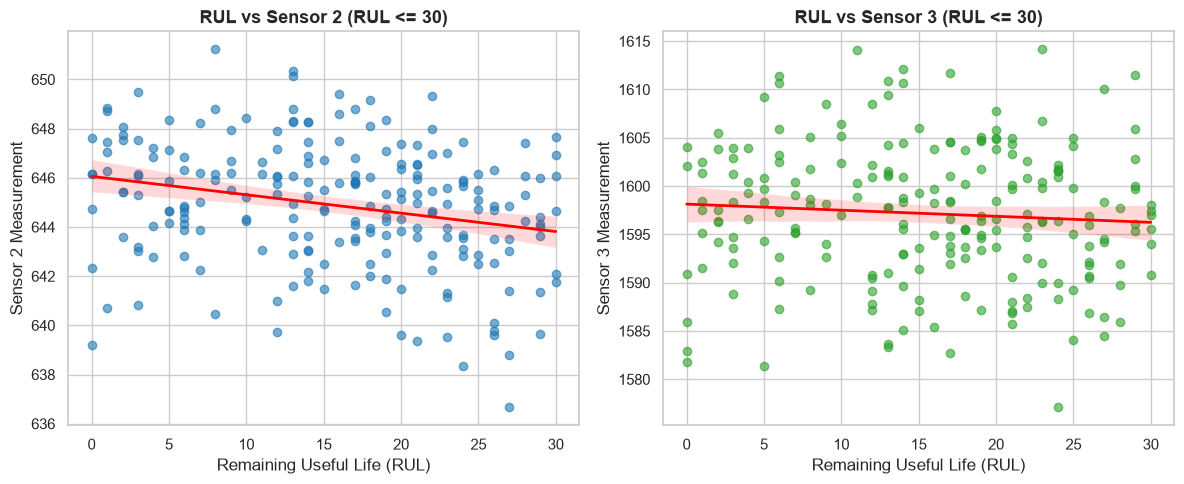

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# 스타일 설정
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# 서브플롯 1: RUL vs sensor_2
plt.subplot(1, 2, 1)
sns.regplot(
    data=result,
    x="RUL",
    y="sensor_2",
    scatter_kws={"alpha": 0.6, "color": "#1f77b4"},
    line_kws={"color": "red", "linewidth": 2},
)
plt.title("RUL vs Sensor 2 (RUL <= 30)", fontsize=13, fontweight="bold")
plt.xlabel("Remaining Useful Life (RUL)")
plt.ylabel("Sensor 2 Measurement")

# 서브플롯 2: RUL vs sensor_3
plt.subplot(1, 2, 2)
sns.regplot(
    data=result,
    x="RUL",
    y="sensor_3",
    scatter_kws={"alpha": 0.6, "color": "#2ca02c"},
    line_kws={"color": "red", "linewidth": 2},
)
plt.title("RUL vs Sensor 3 (RUL <= 30)", fontsize=13, fontweight="bold")
plt.xlabel("Remaining Useful Life (RUL)")
plt.ylabel("Sensor 3 Measurement")

plt.tight_layout()
plt.show()

# 이번엔 MIMII를 읽어봅시다

In [54]:
# CSV 파일을 직접 쿼리하여 상위 5개 행을 pandas DataFrame으로 확인
df_sample = duckdb.sql(
    """
    SELECT * 
    FROM '28_mimii_features_sample.csv' 
    LIMIT 5
"""
).df()

print(df_sample)

      rms  spectral_centroid  zero_crossing_rate  label
0  0.3139          1559.7601              0.0409      0
1  0.2500          2058.8049              0.0958      0
2  0.4026          2043.1028              0.1306      1
3  0.3418          1816.1043              0.0449      0
4  0.2051          1523.1356              0.0835      0


음향 피처 요약 집계 (정상 vs 이상 음향 통계 비교)
- 음향 분석의 핵심 지표(진폭 실효값 RMS, 스펙트럼 중심, 영교차율)가 정상(label=0)과 이상(label=1) 상태에서 어떻게 다른지 SQL의 집계 함수(AVG, STDDEV, MIN, MAX)로 한 번에 요약합니다.

In [55]:
query = """
    SELECT 
        CASE 
            WHEN label = 0 THEN 'Normal (0)' 
            ELSE 'Anomaly (1)' 
        END AS status,
        COUNT(*) AS sample_count,
        -- RMS (신호 크기/에너지)
        ROUND(AVG(rms), 4) AS avg_rms,
        ROUND(STDDEV_SAMP(rms), 4) AS std_rms,
        -- Spectral Centroid (음향의 주파수 중심)
        ROUND(AVG(spectral_centroid), 1) AS avg_centroid,
        -- Zero Crossing Rate (신호 부호 전환율)
        ROUND(AVG(zero_crossing_rate), 4) AS avg_zcr
    FROM '28_mimii_features_sample.csv'
    GROUP BY label
    ORDER BY label ASC
"""

feature_summary = duckdb.sql(query).df()
print(feature_summary)

        status  sample_count  avg_rms  std_rms  avg_centroid  avg_zcr
0   Normal (0)           627   0.2975   0.0446        1800.9   0.0804
1  Anomaly (1)           173   0.4082   0.0468        2193.5   0.1223


이상치 후보 추출 및 조건 필터링 (Feature Screening)
- 이상 음향의 특성(진폭이 크거나 주파수 중심이 높은 패턴)에 해당하는 샘플만 디스크 레벨에서 빠르게 필터링해 가져옵니다.

In [56]:
# RMS가 높고(> 0.4) 스펙트럼 중심이 높은(> 2000Hz) 고위험 소음 데이터 필터링
high_noise_query = """
    SELECT 
        rms,
        spectral_centroid,
        zero_crossing_rate,
        label
    FROM '28_mimii_features_sample.csv'
    WHERE rms >= 0.40 AND spectral_centroid >= 2000
    ORDER BY rms DESC
"""

high_noise_df = duckdb.sql(high_noise_query).df()
print(
    f"고위험 소음 조건 만족 건수: {len(high_noise_df)}건 (이상 비율: {high_noise_df['label'].mean():.1%})"
)
print(high_noise_df.head())

고위험 소음 조건 만족 건수: 81건 (이상 비율: 100.0%)
      rms  spectral_centroid  zero_crossing_rate  label
0  0.5121          2556.8287              0.1108      1
1  0.5118          2273.3219              0.1316      1
2  0.5098          2451.7147              0.1154      1
3  0.4968          2517.2740              0.1039      1
4  0.4962          2156.0014              0.1008      1


시각화(seaborn)로 바로 연결하기
- 추출한 데이터를 기존에 배운 seaborn에 넣어 정상과 이상의 음향 특징 차이를 시각화합니다.

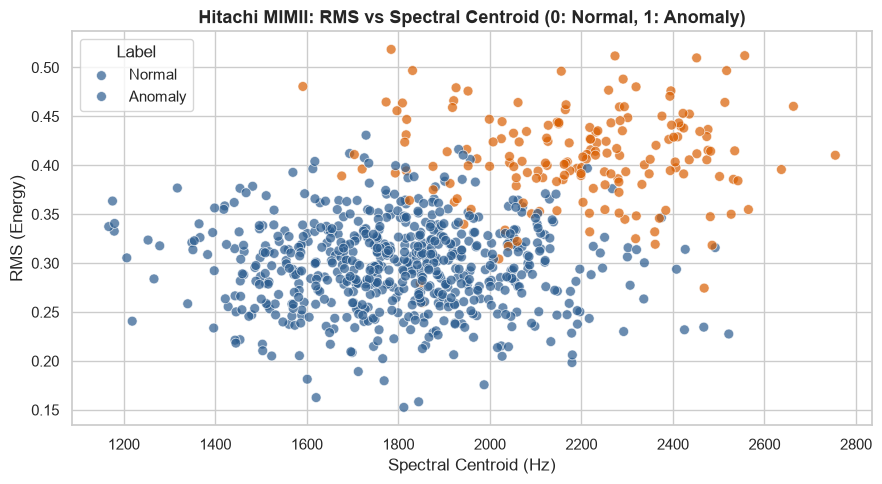

In [57]:
# 전체 데이터를 DuckDB로 읽어오기
mimii_df = duckdb.sql("SELECT * FROM '28_mimii_features_sample.csv'").df()

# 시각화: RMS vs Spectral Centroid 산점도 (정상 vs 이상 분류)
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=mimii_df,
    x="spectral_centroid",
    y="rms",
    hue="label",
    palette={0: "#2b5c8f", 1: "#d95f02"},
    alpha=0.7,
    s=50,
)
plt.title(
    "Hitachi MIMII: RMS vs Spectral Centroid (0: Normal, 1: Anomaly)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Spectral Centroid (Hz)")
plt.ylabel("RMS (Energy)")
plt.legend(title="Label", labels=["Normal", "Anomaly"])
plt.tight_layout()
plt.show()

# DuckDB와 Pandas의 DataFrame은 완전히 호환됩니다
- pandas 고유 메서드: .info(), .describe(), .iloc, .loc, .apply() 등 즉시 사용 가능
- 시각화: seaborn, matplotlib의 data= 파라미터로 직행
- 머신러닝: scikit-learn의 fit(X, y)나 train_test_split()에 전달 가능

In [58]:
import duckdb
import pandas as pd

res = duckdb.sql("SELECT 1 AS col").df()

print(type(res))
# <class 'pandas.core.frame.DataFrame'>

print(isinstance(res, pd.DataFrame))

<class 'pandas.DataFrame'>
True


기능은 100% 호환되지만, 데이터 타입 매핑 과정에서 생길 수 있는 차이점
- 정수형 결측치 처리:
    - pandas 순정 read_csv는 결측치(NULL)가 섞인 정수 컬럼을 자동으로 float64로 바꾸는 경향이 있습니다.
    - DuckDB의 .df()는 내부적으로 pandas의 최신 Nullable 타입(Int64) 등을 적극 활용하거나 화살표 확장을 써서 정수 형태를 온전히 보존해 반환합니다.

- 시간대(Timestamp) 처리:
    - 날짜/시간 컬럼의 세부 단위(초, 밀리초, 마이크로초)나 타임존 속성이 DuckDB의 원본 규격에 맞춰 datetime64[us] 등으로 정밀하게 매핑됩니다.
